In [2]:
#Loading important dependencies
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import models

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


2026-04-07 13:46:34.943666: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
#Loading data using 'keras.utils.image_dataset_from_directory' for a default scaling 
data = tf.keras.utils.image_dataset_from_directory('./tomato/train/')
val = tf.keras.utils.image_dataset_from_directory('./tomato/val/')
classes = {'Bacterial_spot','Early_blight','Late_blight','Leaf_Mold','Septoria_leaf_spot','Spider_mites Two-spotted_spider_mite','Target_Spot','Yellow_Leaf_Curl_Virus','mosaic_virus','healthy'}

Found 10000 files belonging to 10 classes.
Found 1000 files belonging to 10 classes.


In [4]:
"""
What happens under the hood:
    Conversion: It transforms every element in your dataset from a tf.Tensor into a numpy.ndarray.
    
    Iterability: It allows you to use the standard Python next() function to grab one batch at a time.
    
    Readability: It makes it much easier to inspect your data, check shapes, or use libraries like Matplotlib and OpenCV that expect NumPy inputs.
"""
data_iterator = data.as_numpy_iterator()

In [5]:
"""
Think of your data_iterator as a vending machine and .next() as pressing the button. Until you call .next(), the images are just sitting on your hard drive. Once you call it, TensorFlow goes into those tomato folders, grabs a batch (usually 32 images), processes them, and hands them to you as a NumPy array.
"""
batch = data_iterator.next() 

In [6]:
batch[0].shape

(32, 256, 256, 3)

In [7]:
"""
Yes, you absolutely need to divide by 255 because it normalizes your data, which is essential for deep learning.

Why it's required:
Faster Training: Large values (0–255) cause "exploding gradients," making the math unstable. Scaling to 0–1 keeps updates small and steady.

Model "Vision": Activation functions (like Sigmoid or Softmax) are most sensitive near 0. If you feed them 255, they "saturate" (flatten out), and the model stops learning.

Uniformity: It ensures all input features are on the same scale, which is a standard requirement for almost all computer vision models.
"""

'\nYes, you absolutely need to divide by 255 because it normalizes your data, which is essential for deep learning.\n\nWhy it\'s required:\nFaster Training: Large values (0–255) cause "exploding gradients," making the math unstable. Scaling to 0–1 keeps updates small and steady.\n\nModel "Vision": Activation functions (like Sigmoid or Softmax) are most sensitive near 0. If you feed them 255, they "saturate" (flatten out), and the model stops learning.\n\nUniformity: It ensures all input features are on the same scale, which is a standard requirement for almost all computer vision models.\n'

In [8]:
scaled_batch = batch[0]/255
scaled_batch.shape

(32, 256, 256, 3)

In [9]:
data = data.map(lambda x, y: (x / 255.0, y))
val = val.map(lambda x, y: (x / 255.0, y))

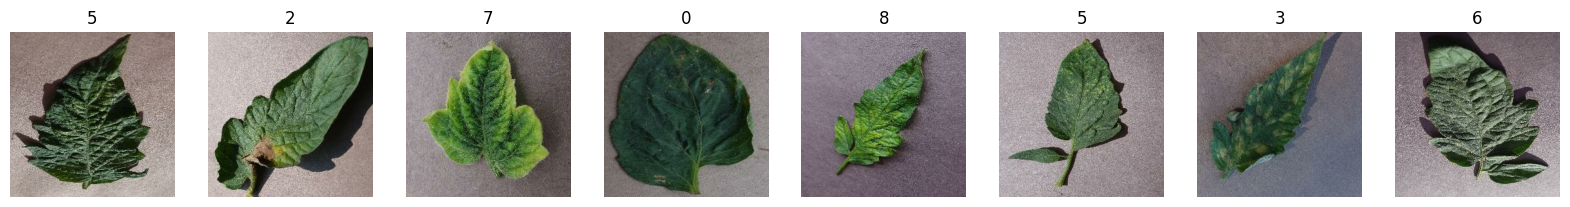

In [10]:
fig, ax = plt.subplots(ncols=8,figsize=(20,20))
for i in range(8):
    ax[i].imshow(scaled_batch[i])
    ax[i].title.set_text(batch[1][i])
    ax[i].axis('off')

plt.show()
    

In [11]:
model = models.Sequential([
    layers.Input(shape=(256, 256, 3)),
    
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2), strides=(3, 3)),
    
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2), strides=(3, 3)),

    layers.Conv2D(128, (3,3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2), strides=(3, 3)),

    layers.Conv2D(256, (3,3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2), strides=(3, 3)),
    
    layers.Flatten(),
    
    layers.Dense(120, activation='relu'),
    layers.Dense(84, activation='relu'),
    layers.Dense(10, activation='softmax'),
])

/home/yasser/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 85, 85, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 83, 83, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │       123,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 522,430 (1.99 MB)

 Trainable params: 522,430 (1.99 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [14]:
history = model.fit(data, epochs=5, validation_data=val)

Epoch 1/5


2026-04-07 13:46:55.181291: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 264257536 exceeds 10% of free system memory.
2026-04-07 13:46:55.422808: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 29593600 exceeds 10% of free system memory.
2026-04-07 13:46:55.440692: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 56434688 exceeds 10% of free system memory.
2026-04-07 13:46:55.588013: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 56434688 exceeds 10% of free system memory.
2026-04-07 13:46:55.615443: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 29593600 exceeds 10% of free system memory.


313/313 ━━━━━━━━━━━━━━━━━━━━ 220s 698ms/step - accuracy: 0.3917 - loss: 1.6131 - val_accuracy: 0.6350 - val_loss: 0.9937
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 221s 704ms/step - accuracy: 0.7125 - loss: 0.8066 - val_accuracy: 0.7670 - val_loss: 0.6754
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 225s 718ms/step - accuracy: 0.7902 - loss: 0.5901 - val_accuracy: 0.6870 - val_loss: 1.0117
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 224s 716ms/step - accuracy: 0.8359 - loss: 0.4617 - val_accuracy: 0.8190 - val_loss: 0.5375
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 220s 701ms/step - accuracy: 0.8611 - loss: 0.3860 - val_accuracy: 0.8430 - val_loss: 0.4947


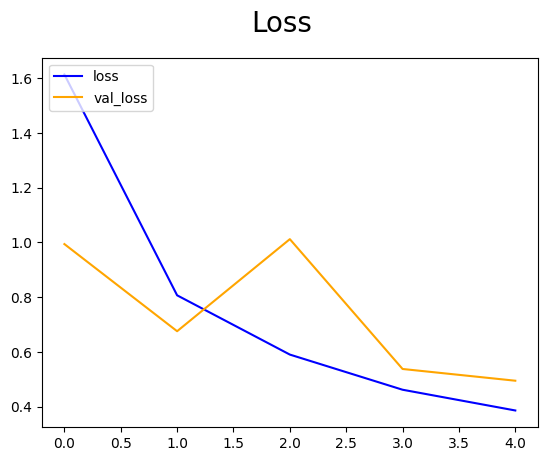

In [15]:
fig = plt.figure()
plt.plot(history.history['loss'], color='blue', label='loss')
plt.plot(history.history['val_loss'], color='orange', label='val_loss')
plt.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

In [16]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

In [17]:
pre = Precision()
re = Recall()
acc = BinaryAccuracy()

In [18]:
# This one line replaces your entire manual loop
print("Final Evaluation on Validation Set:")
results = model.evaluate(val)

# results[0] is Loss, results[1] is Accuracy
print(f"Loss: {results[0]:.4f}")
print(f"Validation Accuracy: {results[1]*100:.2f}%")

Final Evaluation on Validation Set:
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 186ms/step - accuracy: 0.8430 - loss: 0.4947
Loss: 0.4947
Validation Accuracy: 84.30%


In [19]:
print(f'Precision: {pre.result()}, Recall: {re.result()}, Accuracy: {acc.result()}')

Precision: 0.0, Recall: 0.0, Accuracy: 0.0


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

2026-04-07 18:48:50.702681: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


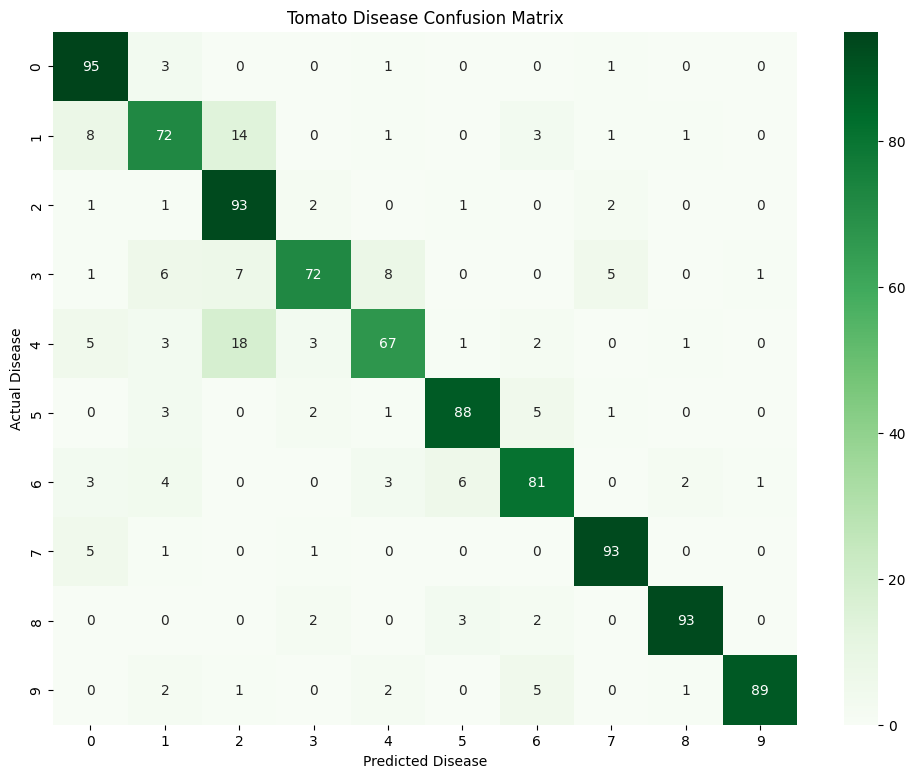

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# 1. Get all true labels and predictions
y_true = []
y_pred = []

for batch in val:
    X, y = batch
    yhat = model.predict(X)
    y_true.extend(y.numpy())
    y_pred.extend(np.argmax(yhat, axis=1))

# 2. Plot the Heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted Disease')
plt.ylabel('Actual Disease')
plt.title('Tomato Disease Confusion Matrix')
plt.show()

In [20]:
!pip install seaborn

In [21]:
from tensorflow.keras.models import load_model
import os

In [22]:
model.save(os.path.join('models','model.h5'))

In [25]:
print(train_generator.class_indices)

NameError: name 'train_generator' is not defined

In [34]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Re-initialize the generator exactly like you did for training
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
path = '/home/yasser/Codes/AI/DeepLearning/P1/tomato/train'
# 2. Point it to your data folder
temp_generator = train_datagen.flow_from_directory(
    path, # Replace with your actual path
    target_size=(256, 256),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

# 3. Now print the indices
print(temp_generator.class_indices)

Found 8005 images belonging to 10 classes.
{'Tomato___Bacterial_spot': 0, 'Tomato___Early_blight': 1, 'Tomato___Late_blight': 2, 'Tomato___Leaf_Mold': 3, 'Tomato___Septoria_leaf_spot': 4, 'Tomato___Spider_mites Two-spotted_spider_mite': 5, 'Tomato___Target_Spot': 6, 'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 7, 'Tomato___Tomato_mosaic_virus': 8, 'Tomato___healthy': 9}


In [33]:
import os
folders = sorted(os.listdir('/home/yasser/Codes/AI/DeepLearning/P1/tomato/train'))
for i, folder in enumerate(folders):
    print(f"Index {i}: {folder}")

Index 0: Tomato___Bacterial_spot
Index 1: Tomato___Early_blight
Index 2: Tomato___Late_blight
Index 3: Tomato___Leaf_Mold
Index 4: Tomato___Septoria_leaf_spot
Index 5: Tomato___Spider_mites Two-spotted_spider_mite
Index 6: Tomato___Target_Spot
Index 7: Tomato___Tomato_Yellow_Leaf_Curl_Virus
Index 8: Tomato___Tomato_mosaic_virus
Index 9: Tomato___healthy
